# Statistics

## Describing a single dataset

We use statistics to distill and communicate relevant features of our data.

As a first approach we can put friend counts into a histogram using ```Counter``` and ```plt.bar```

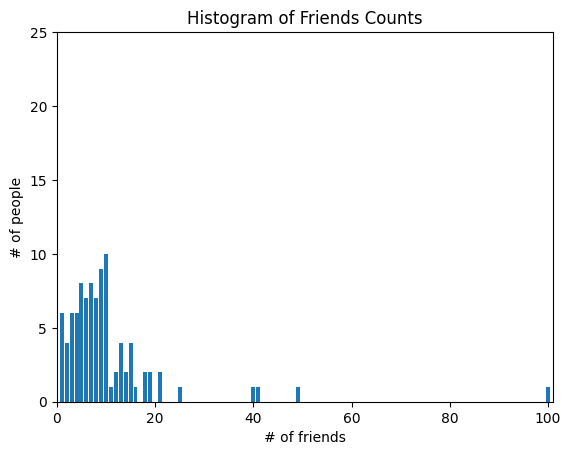

In [96]:
from collections import Counter 
import matplotlib.pyplot as plt 


num_friends = [100, 49, 41, 40, 25, 21, 21, 19, 19,
            18, 18, 16, 15, 15, 15, 15, 14, 14,
            13, 13, 13, 13, 12, 12, 11, 10, 10,
            10, 10, 10, 10, 10, 10, 10, 10, 9,
            9, 9, 9, 9, 9, 9, 9, 9, 8, 8, 8,
            8, 8, 8, 8, 7, 7, 7, 7, 7, 7, 7,
            7, 6, 6, 6, 6, 6, 6, 6, 5, 5, 5,
            5, 5, 5, 5, 5, 4, 4, 4, 4, 4, 4,
            3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 1,
            1, 1, 1, 1, 1]

friend_counts = Counter(num_friends)
xs = range(101)
ys = [friend_counts[x] for x in xs] 
plt.bar(xs, ys)
plt.axis([0, 101, 0, 25])
plt.title("Histogram of Friends Counts")
plt.xlabel("# of friends")
plt.ylabel("# of people")
plt.show()

Unfortunately, this chart is still too difficult to slit into conversations. We can start generating some statistics. Most simplest statistic is the number of data points:

In [97]:
num_points = len(num_friends)



Largest and Smallest values:

In [98]:
largest_value   = max(num_friends) # 100
smallest_value  = min(num_friends) # 1

Which are just special cases of wanting to know the values of specific positions:

In [99]:
sorted_values           = sorted(num_friends)
smallest_value          = sorted_values[0]
second_smallest_value   = sorted_values[1]
second_largest_value    = sorted_values[-2]

### Central Tendencies

We can use the *mean* (average), which is the sum of the data divided by its count:

In [100]:
from typing import List

def mean(xs: List[float]) -> float:
    return sum(xs) / len(xs)

mean_of_friends = mean(num_friends)
print(mean_of_friends)

10.34375


If you have two data points, the mean is simply the point halfway between them. As you add more points, the mean shifts around, but it always depends on the value of every point. For example, if you have 10 data points, and you increase the value of any of them by 1, you increase the mean by 0.1. 


We'll also sometimes be interested in the *median*, which is the middle-most value (if the number of data points is odd) or the average of the two middle-most values (if the number of data points is even). 



In [101]:
# The underscore indicate that these are "private" functions, as they're
# intended to be called by our median function but not by other people
# using our statistics library

def _median_odd(xs: List[float]) -> float:
    """If len(xs) is odd, the median is the middle element"""
    return sorted(xs)[len(xs)//2]

def _median_even(xs: List[float]) -> float:
    """If len(xs) is even, it's the average of the middle two elements"""
    sorted_xs = sorted(xs)
    hi_midpoint = len(xs) // 2 # gets the mid point
    return (sorted_xs[hi_midpoint - 1] + sorted_xs[hi_midpoint]) / 2

def median(v: List[float]) -> float:
    """Finds the 'middle-most value of v"""
    return _median_even(v) if len(v) % 2 == 0 else _median_odd(v)

assert median([1, 10, 2, 9, 5]) == 5
assert median([1, 9, 2, 10]) == (2 + 9) / 2

A generalization of the median is the *quantile*, which represents the value under which a certain percentile of the data lies (the median represents the value under the 50\% of the data lies):

In [102]:
def quantile(xs: List[float], p: float) -> float:
    """Returns the pth-percentile value in x"""
    p_index = int(p * len(xs))
    return sorted(xs)[p_index]

print(quantile(num_friends, 0.10))
print(quantile(num_friends, 0.25))
print(quantile(num_friends, 0.75))
print(quantile(num_friends, 0.90))

2
5
12
18


Less commonly you might want to look at the *mole*, or the most common value(s):

In [103]:
def mode(x: List[float]) -> List[float]:
    """Returns a list, since there might be more than one mode"""
    counts = Counter(x)
    max_count = max(counts.values())
    return [x_i for x_i, count in counts.items() if count == max_count]

print(mode(num_friends))

[10]


### Dispersion

*Dispersion* refers to measures of how spread out our data is. Typically they're statistics for which values near zero signify *not spread out at all* and for which large values signify *very spread out*. For instance, a very simple measure is the *range*, which is just the difference between the largest and smallest elements:

In [104]:
def data_range(xs: List[float]) -> float:
    return max(xs) - min (xs)

print(data_range(num_friends))

99


The range is zero precisely when the ```max``` and ```min``` are equal, which can only happen if the elements of ```x``` are all the same, which means the data is as undispered as possible. Conversely, if the range is large, then the ```max``` is much larger than the ```min``` and the data is more spread out. 

Like the median, the range doesn't really depend on the whole dataset. A dataset whose poitns are all either 0 or 100 has the same range as a dataset whose values are 0, 100, and lots of 50s. But it seems like the first dataset "should" be more spread out. 

As a more complex measure of dispersion is the *variance*, which is computed as:

In [105]:
from typing import List

def sum_of_squares(xs: List[float]) -> float:
    """Returns x₁² + x₂² + ... + xₙ²"""
    return sum(x * x for x in xs)

def de_mean(xs: List[float]) -> List[float]:
    """Translate xs by subtracting its mean (so the result has mean 0)"""
    x_bar = mean(xs)
    return [x - x_bar for x in xs]
    
def variance(xs: List[float])->float:
    """Almost the average squared deviation from the mean"""
    assert len(xs) >= 2, "variance requires at least two elements"
    
    n = len(xs)
    deviations = de_mean(xs)
    return sum_of_squares(deviations) / (n - 1)
    

In [106]:
def interquartile_range(xs: List[float]) -> float:
    """Returns the difference between the 75%-ile and the 25%-ile"""
    return quantile(xs, 0.75) - quantile(xs, 0.25)

## Correlation

Investigating the relationship between two metrics. We'll first look at *covariance*. Covariance
measures how two variables vary in tandem from their means:

In [107]:
import numpy as np
def corvariance(xs: List[float], ys: List[float]) -> float:
    assert len(xs) == len(ys), "xs and ys must have the same number of elements"
    
    return np.dot(de_mean(xs), de_mean(ys)) / (len(xs) - 1)



When one is above its mean and the other below, a negative number enters the sum. Accordingly, a "large" positive covariance means that $x$ tends to be large when $y$ is large and small when $y$ is small. A "large" negative covariance means the opposite—that $x$ tends to be small when $y$ is large and vice versa. A covariance close to zero means that no such relationship exists.

It is more common to. look at the *correlation*, which divides out the standard deviations of both variables:

In [108]:

def standard_deviation(xs: List[float]) -> float:
    """Returns the standard deviation of xs"""
    return np.sqrt(variance(xs))

def correlation(xs: List[float], ys: List[float]) -> float:
    """ Measures how much xs and ys very in tandem about their means"""
    stdev_x = standard_deviation(xs)
    stdev_y = standard_deviation(ys)
    if stdev_x > 0 and stdev_y > 0:
        return np.cov(xs, ys) / stdev_x / stdev_y
    else:
        return 0 # if no variation, correlation is zero

## Simpson's Paradox

**What is it?**
A trend that appears in several groups of data **disappears or reverses** when the groups are combined. The aggregate statistic lies to you because it ignores a lurking variable that's unevenly distributed across groups.

---

**Classic example — hospital survival rates**

Two hospitals, two patient conditions (mild vs. serious):

| Hospital | Mild cases | Serious cases | Overall survival |
|----------|-----------|---------------|-----------------|
| A | 93% (800 pts) | 57% (200 pts) | 83% |
| B | 87% (100 pts) | 47% (900 pts) | 49% |

Hospital A beats Hospital B in *both* groups — yet overall, A looks worse than B if you flip the patient mix. Hospital B happens to see mostly mild cases, inflating its aggregate.

---

**Why it matters for data science**

Aggregating data before you understand its subgroups can completely reverse your conclusion. Always ask:

- Is there a confounding variable (e.g. severity, age, group size) that is unevenly distributed?
- Should I be looking at conditional correlations instead of a single aggregate one?

Simpson's paradox is one reason a correlation computed on pooled data can be meaningless or misleading.

<details>
<summary><strong>Correlation and Causation</strong></summary>

"Correlation is not causation" — if $x$ and $y$ are strongly correlated, there are several possible explanations:

- $x$ causes $y$
- $y$ causes $x$
- Each causes the other
- Some third factor causes both
- Pure coincidence

**Example:** `num_friends` and `daily_minutes` are correlated on DataSciencester. But why?

1. More friends → more content to read → more time on site
2. More time on site → more people met → more friends
3. Passionate users do both independently

**The fix: randomized trials.** Split users into two groups with similar demographics, give them slightly different experiences, and observe the outcomes. If the group shown content from fewer friends spends less time on the site, that's evidence the number of friends *causes* time spent — not just correlates with it.

</details>